# Figure 1: Benchmark Design

| Panel | Content |
|---|---|
| **1A** | Dataset Landscape — bubble chart (65 datasets) |
| **1B** | Tool Landscape — technical approaches comparison |
| **1C** | Seven-Dimension Evaluation Framework + Reproducibility |

**Data source**: `benchmark_testcases.json`, icon files in `/benchmark/icons/`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('/benchmark/results')
DATA_DIR = Path('/benchmark/data/generated')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')
TMP_DIR = Path('/tmp/notebook_work')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#00a69d', 'failed': '#be1818', 'na': '#999999',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

def extract_error_reason(stderr_text):
    """Extract a short error reason from R/tool stderr output."""
    if not stderr_text:
        return 'unknown error'
    for line in stderr_text.split('\n'):
        line = line.strip()
        if line.startswith('Error') or 'error' in line.lower():
            return line[:120] + ('...' if len(line) > 120 else '')
    lines = [l.strip() for l in stderr_text.strip().split('\n') if l.strip()]
    if lines:
        return lines[-1][:120]
    return 'unknown error'

import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

FIGURES_DIR = FIGURES_DIR_MAIN
CONFIG_DIR = Path('/benchmark/config')
TESTCASES_FILE = CONFIG_DIR / 'benchmark_testcases.json'
ICONS_DIR = Path('/benchmark/icons') if Path('/benchmark/icons').exists() else Path('benchmark/icons')

with open(TESTCASES_FILE) as f:
    testcases = json.load(f)

print(f'Loaded {testcases["summary"]["total_test_cases"]} test cases')
print(f'Icons dir: {ICONS_DIR} (exists={ICONS_DIR.exists()})')

# ── Shared constants for all Fig 1 panels ──
CC_PINK = '#025e8d'
CC_BG   = '#f0f7fc'
TXT1    = '#222222'
TXT2    = '#555555'
CARD_BG = '#f8f8f8'
CARD_BD = '#999999'
BADGE_BG = '#f8f8f8'
BADGE_BD = '#999999'
DIM_AXIS = '#dadada'
AXIS_CLR = '#999999'
SCALE_COLORS = {'small': '#00a69d', 'medium': '#f58220', 'large': '#025e8d'}

# Consistent font sizes across all panels
TITLE_FS = 11
LABEL_FS = 9
TICK_FS = 8
SMALL_FS = 7.5

def load_icon(filename, target_h=20):
    path = ICONS_DIR / filename
    if not path.exists():
        print(f'  WARN: icon missing: {path}')
        return None
    try:
        img = mpimg.imread(str(path))
        return OffsetImage(img, zoom=target_h / img.shape[0])
    except Exception as e:
        print(f'  ERROR loading {path}: {e}')
        return None

TOOLS_1B = [
    {'name': 'Zellkonverter',   'desc': 'R\u2192Python bridge (basilisk) \u2014 needs R + Python',
     'icons': ['r_logo.png', 'python_logo.png'], 'direction': '\u2194', 'deps': 'Runtime Deps: R, Python', 'hl': False},
    {'name': 'anndataR',        'desc': 'Native R (hdf5r) \u2014 needs R only',
     'icons': ['r_logo.png', 'file_logo.png'],   'direction': '\u2190', 'deps': 'Runtime Deps: R', 'hl': False},
    {'name': 'convert2anndata', 'desc': 'R\u2192Python bridge (reticulate) \u2014 needs R + Python',
     'icons': ['r_logo.png', 'python_logo.png'], 'direction': '\u2192', 'deps': 'Runtime Deps: R, Python', 'hl': False},
    {'name': 'easySCF',         'desc': 'Custom HDF5 intermediate \u2014 needs R + Python',
     'icons': ['hdf5_logo.png', 'file_logo.png'],'direction': '\u2194', 'deps': 'Runtime Deps: R, Python', 'hl': False},
    {'name': 'CrossCell',       'desc': 'Native Rust (no runtime) \u2014 standalone binary',
     'icons': ['rust_logo.png', 'file_logo.png'],'direction': '\u2194', 'deps': 'Runtime Deps: None', 'hl': True},
]

DIMENSIONS = [
    {'label': 'Conversion\nRobustness',   'icon': 'icon_shield.png',    'emoji': '\U0001f6e1', 'idx': 0},
    {'label': 'Runtime\nPerformance',     'icon': 'icon_clock.png',     'emoji': '\u23f1',     'idx': 1},
    {'label': 'Memory\nEfficiency',       'icon': 'icon_chip.png',      'emoji': '\U0001f4be', 'idx': 2},
    {'label': 'Expression\nFidelity',     'icon': 'icon_checkmark.png', 'emoji': '\u2713',     'idx': 3},
    {'label': 'Type\nIntegrity',          'icon': 'icon_lock.png',      'emoji': '\U0001f512', 'idx': 4},
    {'label': 'V5\nCompatibility',        'icon': 'icon_layers.png',    'emoji': '\U0001f4da', 'idx': 5},
    {'label': 'Large-scale\nScalability', 'icon': 'icon_scaleup.png',   'emoji': '\U0001f4c8', 'idx': 6},
]

REPRO_ITEMS = [
    {'icon': 'icon_docker.png',    'emoji': '\U0001f433', 'text': 'Version-locked environment'},
    {'icon': 'icon_replicate.png', 'emoji': '3\u00d7',    'text': '3\u00d7 replicate runs per test'},
    {'icon': 'icon_github.png',    'emoji': '\U0001f517', 'text': 'All code, data, notebooks public'},
    {'icon': 'icon_grid.png',      'emoji': '\U0001f4ca', 'text': '65 datasets \u00d7 5 tools \u00d7 7 dim = 2,275 test points'},
]

def draw_panel_a(ax, rows, source_order):
    """Draw Dataset Landscape bubble chart on given axes."""
    import matplotlib.patches as mpatches
    source_x = {s: i for i, s in enumerate(source_order)}
    np.random.seed(42)
    for r in rows:
        x_base = source_x.get(r['source'], 0)
        x = x_base + np.random.uniform(-0.25, 0.25)
        size = np.clip(r['n_genes'] / 500, 15, 200)
        color = SCALE_COLORS.get(r['scale'], '#999')
        marker = 's' if r['spatial'] else 'o'
        ax.scatter(x, r['n_cells'], s=size, c=color, marker=marker,
                   alpha=0.7, edgecolor='white', linewidth=0.5, zorder=3)

    ax.axvline(x=1.6, color='#999999', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_yscale('log')
    ax.set_xticks(range(len(source_order)))
    ax.set_xticklabels(source_order, rotation=0, ha='center', fontsize=TICK_FS)
    ax.set_ylabel('Number of Cells (log scale)', fontsize=LABEL_FS)
    ax.tick_params(axis='y', labelsize=TICK_FS)
    ax.text(0.5, 1.08, 'Dataset Landscape: 65 Benchmark Datasets',
            transform=ax.transAxes, fontsize=TITLE_FS, fontweight='bold',
            ha='center', va='center', color=TXT1, fontfamily='sans-serif')

    from matplotlib.lines import Line2D
    tier_patches = [mpatches.Patch(color=SCALE_COLORS[s], label=l)
                    for s, l in [('small', 'Small (<10k)'), ('medium', 'Medium (10k-100k)'), ('large', 'Large (\u226510k)')]]
    leg1 = ax.legend(handles=tier_patches, loc='upper left', fontsize=SMALL_FS,
                     title='Cell Count', title_fontsize=TICK_FS, bbox_to_anchor=(0.0, 1.0))
    ax.add_artist(leg1)

    spatial_h = [Line2D([0], [0], marker='o', color='gray', label='Transcriptomic', markersize=6, linestyle=''),
                 Line2D([0], [0], marker='s', color='gray', label='Spatial', markersize=6, linestyle='')]
    leg2 = ax.legend(handles=spatial_h, loc='upper left', fontsize=SMALL_FS,
                     title='Data Type', title_fontsize=TICK_FS, bbox_to_anchor=(0.28, 1.0))
    ax.add_artist(leg2)

    size_handles = [
        Line2D([0], [0], marker='o', color='#999999', markersize=np.sqrt(np.clip(500/500, 15, 200)),
               label='<1k genes', linestyle=''),
        Line2D([0], [0], marker='o', color='#999999', markersize=np.sqrt(np.clip(10000/500, 15, 200)),
               label='1k\u201320k genes', linestyle=''),
        Line2D([0], [0], marker='o', color='#999999', markersize=np.sqrt(np.clip(40000/500, 15, 200)),
               label='>20k genes', linestyle=''),
    ]
    leg3 = ax.legend(handles=size_handles, loc='upper left', fontsize=SMALL_FS,
                     title='Gene Count', title_fontsize=TICK_FS, bbox_to_anchor=(0.0, 0.85))
    ax.add_artist(leg3)

    n_rds = sum(1 for r in rows if r['format'] == 'RDS')
    n_h5ad = sum(1 for r in rows if r['format'] == 'H5AD')
    n_cx = sum(1 for r in rows if r['source'] == 'CELLxGENE')
    ax.text(0.28, 0.85, f'{len(rows)} datasets\n{n_rds} RDS + {n_h5ad} H5AD\nCELLxGENE: {n_cx}',
            transform=ax.transAxes, ha='left', va='top', fontsize=SMALL_FS,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#ccc', linewidth=0.8))

    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def draw_panel_b(ax):
    """Draw Tool Landscape card layout on given axes."""
    import matplotlib.patches as mpatches
    W_b = 10.0
    ax.set_xlim(0, W_b)
    ax.set_ylim(0, 5.25)
    ax.axis('off')

    ROW_H = 0.85
    TITLE_H_B = 0.45
    y_start_b = 5.25 - TITLE_H_B - 0.1

    ax.text(W_b / 2, 5.25 - 0.15, 'Tool Comparison: Technical Approaches',
            fontsize=TITLE_FS, fontweight='bold', ha='center', va='center',
            color=TXT1, fontfamily='sans-serif')

    outer_b = mpatches.FancyBboxPatch((0.15, 0.1), W_b - 0.3, 5.25 - TITLE_H_B - 0.05,
                                       boxstyle='round,pad=0.08', facecolor='white',
                                       edgecolor=CARD_BD, linewidth=1.0)
    ax.add_patch(outer_b)

    CL, CW = 0.3, W_b - 0.6
    for i, t in enumerate(TOOLS_1B):
        yt = y_start_b - i * ROW_H
        yc = yt - ROW_H / 2
        cy = yt - ROW_H + 0.08

        bg, bc, bw = (CC_BG, CC_PINK, 1.8) if t['hl'] else (CARD_BG, CARD_BD, 0.8)
        card = mpatches.FancyBboxPatch((CL, cy), CW, ROW_H - 0.14,
                                        boxstyle='round,pad=0.06', facecolor=bg,
                                        edgecolor=bc, linewidth=bw)
        ax.add_patch(card)

        nx = CL + 0.2
        ax.text(nx, yc + 0.12, t['name'], fontsize=LABEL_FS, fontweight='bold',
                ha='left', va='center', color=TXT1, fontfamily='sans-serif')

        for j, ic_file in enumerate(t['icons']):
            im = load_icon(ic_file, target_h=12)
            if im is not None:
                ab = AnnotationBbox(im, (nx + j * 0.35, yc - 0.1),
                                    frameon=False, box_alignment=(0, 0.5))
                ax.add_artist(ab)

        dx = nx + len(t['icons']) * 0.35 + 0.15
        ax.text(dx, yc - 0.1, t['desc'], fontsize=SMALL_FS, ha='left', va='center',
                color=TXT2, fontfamily='sans-serif')

        ax_r = CL + CW - 3.6
        db = mpatches.FancyBboxPatch((ax_r - 0.15, yc - 0.12), 0.3, 0.24,
                                      boxstyle='round,pad=0.04', facecolor=BADGE_BG,
                                      edgecolor=BADGE_BD, linewidth=0.6)
        ax.add_patch(db)
        ax.text(ax_r, yc, t['direction'], fontsize=12, ha='center', va='center',
                color=TXT1, fontfamily='sans-serif')

        rx = CL + CW - 1.8
        dtxt = t['deps']
        bw2 = max(len(dtxt) * 0.08, 2.2)
        rb = mpatches.FancyBboxPatch((rx - bw2/2, yc - 0.11), bw2, 0.22,
                                      boxstyle='round,pad=0.04', facecolor=BADGE_BG,
                                      edgecolor=BADGE_BD, linewidth=0.6)
        ax.add_patch(rb)
        ax.text(rx, yc, dtxt, fontsize=SMALL_FS, ha='center', va='center',
                color=TXT2, fontfamily='sans-serif')

def draw_panel_c(ax):
    """Draw Evaluation Framework (radar + reproducibility) on given axes."""
    import matplotlib.patches as mpatches
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')

    ax.text(5.0, 9.7, 'Seven-Dimension Evaluation Framework',
            fontsize=TITLE_FS, fontweight='bold', ha='center', va='center',
            color=TXT1, fontfamily='sans-serif')

    cx_c, cy_c = 5.0, 6.5
    R_outer = 2.2
    R_label = 2.8
    R_icon = 2.45
    N_dim = 7
    angles_c = [np.pi/2 + 2*np.pi*i/N_dim for i in range(N_dim)]

    for r_frac in [0.33, 0.66, 1.0]:
        r = R_outer * r_frac
        ring_a = np.linspace(0, 2*np.pi, 200)
        ax.plot(cx_c + r * np.cos(ring_a + np.pi/2),
                cy_c + r * np.sin(ring_a + np.pi/2),
                color=DIM_AXIS, linewidth=0.6, alpha=0.5)

    for dim in DIMENSIONS:
        a = angles_c[dim['idx']]
        ddx, ddy = np.cos(a), np.sin(a)
        ax.plot([cx_c, cx_c + R_outer*ddx], [cy_c, cy_c + R_outer*ddy],
                color=AXIS_CLR, linewidth=0.8, alpha=0.7)
        ax.plot(cx_c + R_outer*ddx, cy_c + R_outer*ddy,
                'o', color=AXIS_CLR, markersize=3.5, zorder=5)

        im = load_icon(dim['icon'], target_h=18)
        if im is not None:
            ab = AnnotationBbox(im, (cx_c + R_icon*ddx, cy_c + R_icon*ddy),
                                frameon=False, zorder=6)
            ax.add_artist(ab)
        else:
            ax.text(cx_c + R_icon*ddx, cy_c + R_icon*ddy, dim['emoji'],
                    fontsize=12, ha='center', va='center', zorder=6)

        lx = cx_c + R_label * ddx
        ly = cy_c + R_label * ddy
        ha_l = 'center'
        if ddx > 0.3: ha_l = 'left'
        elif ddx < -0.3: ha_l = 'right'
        ax.text(lx, ly, dim['label'], fontsize=TICK_FS, ha=ha_l, va='center',
                color=TXT1, fontfamily='sans-serif', linespacing=1.1)

    poly_r = R_outer * 0.85
    pxs = [cx_c + poly_r * np.cos(a) for a in angles_c]
    pys = [cy_c + poly_r * np.sin(a) for a in angles_c]
    pxs.append(pxs[0]); pys.append(pys[0])
    ax.fill(pxs, pys, color=CC_PINK, alpha=0.12, zorder=2)
    ax.plot(pxs, pys, color=CC_PINK, linewidth=1.5, alpha=0.6, zorder=3)
    ax.text(cx_c, cy_c - 0.15, 'CrossCell', fontsize=LABEL_FS, fontweight='bold',
            ha='center', va='center', color=CC_PINK, alpha=0.8)

    bx, by, bw, bh = 1.0, 0.2, 8.0, 2.4
    repro = mpatches.FancyBboxPatch((bx, by), bw, bh, boxstyle='round,pad=0.12',
                                     facecolor='#f8f8f8', edgecolor=CARD_BD, linewidth=1.0)
    ax.add_patch(repro)
    ax.text(bx + bw/2, by + bh - 0.2, 'Reproducibility',
            fontsize=LABEL_FS, fontweight='bold', ha='center', va='center',
            color=TXT1, fontfamily='sans-serif')
    ax.plot([bx + 0.3, bx + bw - 0.3], [by + bh - 0.38, by + bh - 0.38],
            color=CARD_BD, linewidth=0.6)

    item_spacing = 0.42
    item_start_y = by + bh - 0.58
    for idx, item in enumerate(REPRO_ITEMS):
        iy = item_start_y - idx * item_spacing
        icon_x = bx + 0.5
        im = load_icon(item['icon'], target_h=14)
        if im is not None:
            ab = AnnotationBbox(im, (icon_x, iy), frameon=False, zorder=6)
            ax.add_artist(ab)
        else:
            ax.text(icon_x, iy, item['emoji'], fontsize=10, ha='center', va='center')
        ax.text(icon_x + 0.35, iy, item['text'], fontsize=SMALL_FS, ha='left', va='center',
                color=TXT2, fontfamily='sans-serif')

print('\u2705 Setup complete: constants, helpers, draw functions defined')


Loaded 55 test cases
Icons dir: /benchmark/icons (exists=True)
✅ Setup complete: constants, helpers, draw functions defined


## 1. Prepare Dataset Table

In [2]:

rows = []
for tc in testcases['test_cases'].get('rds_to_h5ad', []):
    sv = tc.get('seurat_version', 'V5')
    rows.append({'test_id': tc['test_id'], 'source': f'SeuratData {sv}', 'format': 'RDS',
                 'n_cells': tc['n_cells'], 'n_genes': tc['n_genes'],
                 'spatial': tc.get('spatial', False)})
for tc in testcases['test_cases'].get('h5ad_to_rds', []):
    src = tc.get('source', 'unknown')
    source_map = {'scanpy': 'scanpy', 'scvelo': 'scvelo', 'cellxgene': 'CELLxGENE', 'squidpy': 'squidpy'}
    rows.append({'test_id': tc['test_id'], 'source': source_map.get(src, src), 'format': 'H5AD',
                 'n_cells': tc['n_cells'], 'n_genes': tc['n_genes'],
                 'spatial': tc.get('spatial', False)})

cellxgene_large = [
    ('cellxgene_skin_bcc_10k', 9841, 26886), ('cellxgene_tabula_liver_22k', 22214, 60606),
    ('cellxgene_kidney_atacseq_37k', 37747, 19276), ('cellxgene_brain_multiome_102k', 101924, 35451),
    ('cellxgene_pancreas_122k', 121916, 32356), ('cellxgene_brain_dlpfc_172k', 172120, 37490),
    ('cellxgene_gut_428k', 428469, 32383), ('cellxgene_heart_486k', 486134, 32383),
    ('cellxgene_hlca_core_585k', 584944, 27402), ('cellxgene_combat_pbmc_836k', 836148, 36306),
    ('cellxgene_eqtl_autoimmune_1.2M', 1248980, 35528),
]
existing_ids = {r['test_id'] for r in rows}
for tid, nc, ng in cellxgene_large:
    if tid not in existing_ids:
        rows.append({'test_id': tid, 'source': 'CELLxGENE', 'format': 'H5AD',
                     'n_cells': nc, 'n_genes': ng, 'spatial': False})

for r in rows:
    r['scale'] = 'small' if r['n_cells'] < 10000 else ('medium' if r['n_cells'] < 100000 else 'large')

source_order = ['SeuratData V4', 'SeuratData V5', 'scanpy', 'scvelo', 'CELLxGENE', 'squidpy']
print(f'Total data points: {len(rows)}')
print(f'Formats: RDS={sum(1 for r in rows if r["format"]=="RDS")}, H5AD={sum(1 for r in rows if r["format"]=="H5AD")}')


Total data points: 66
Formats: RDS=42, H5AD=24


## 2. Fig 1A: Dataset Landscape (standalone)

Saved fig1a


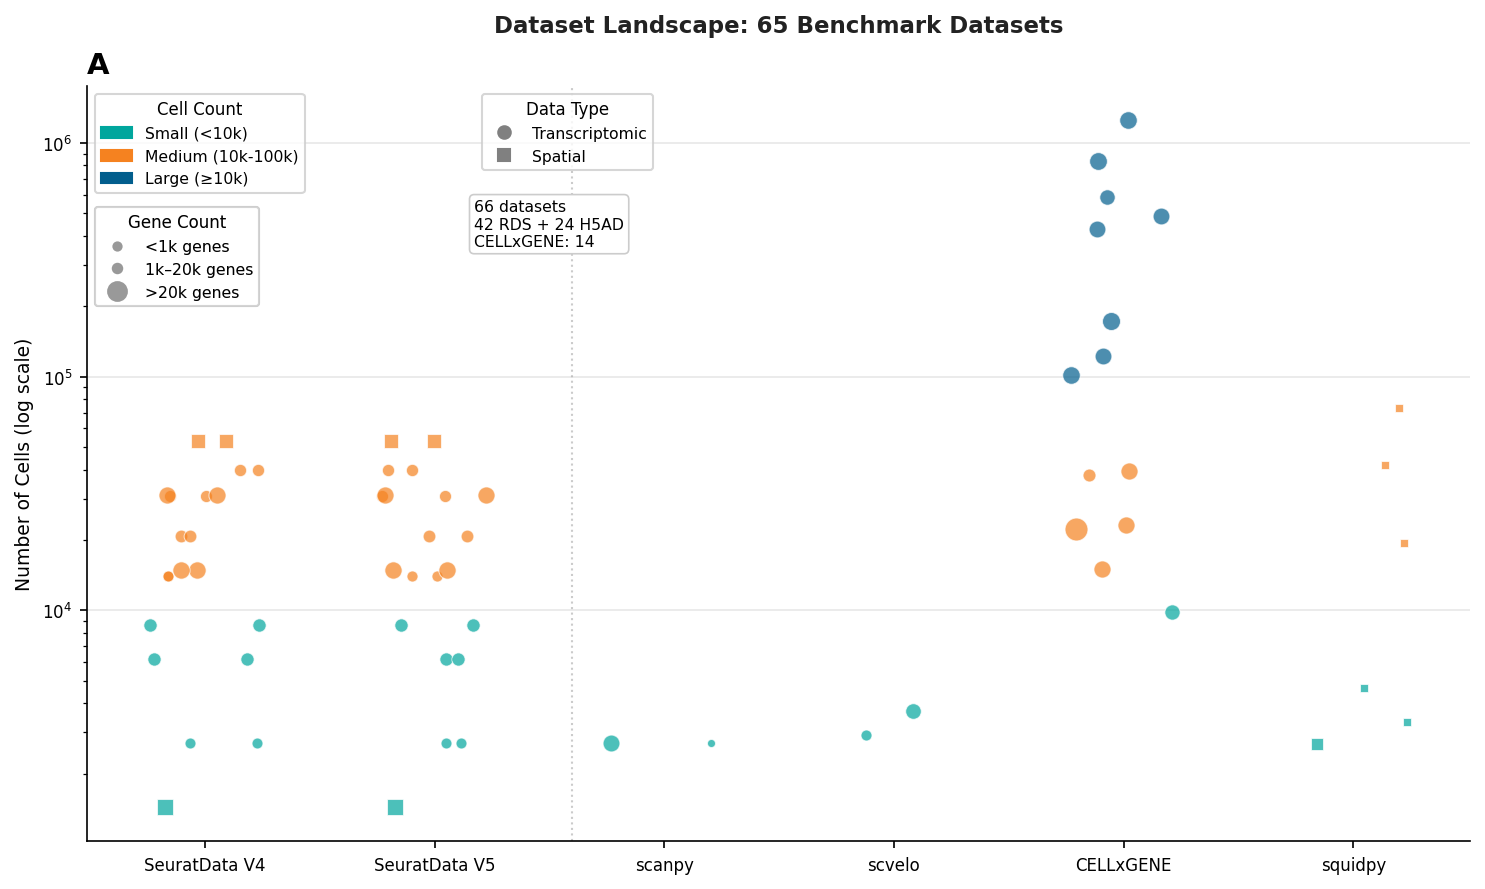

In [3]:

fig, ax = plt.subplots(figsize=(10, 6))
draw_panel_a(ax, rows, source_order)
ax.set_title('A', fontsize=14, fontweight='bold', loc='left', pad=6)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig1a_dataset_landscape.pdf', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIGURES_DIR / 'fig1a_dataset_landscape.png', dpi=300, bbox_inches='tight', facecolor='white')
print('Saved fig1a')
plt.show()


## 3. Fig 1B: Tool Landscape (standalone)

Saved fig1b


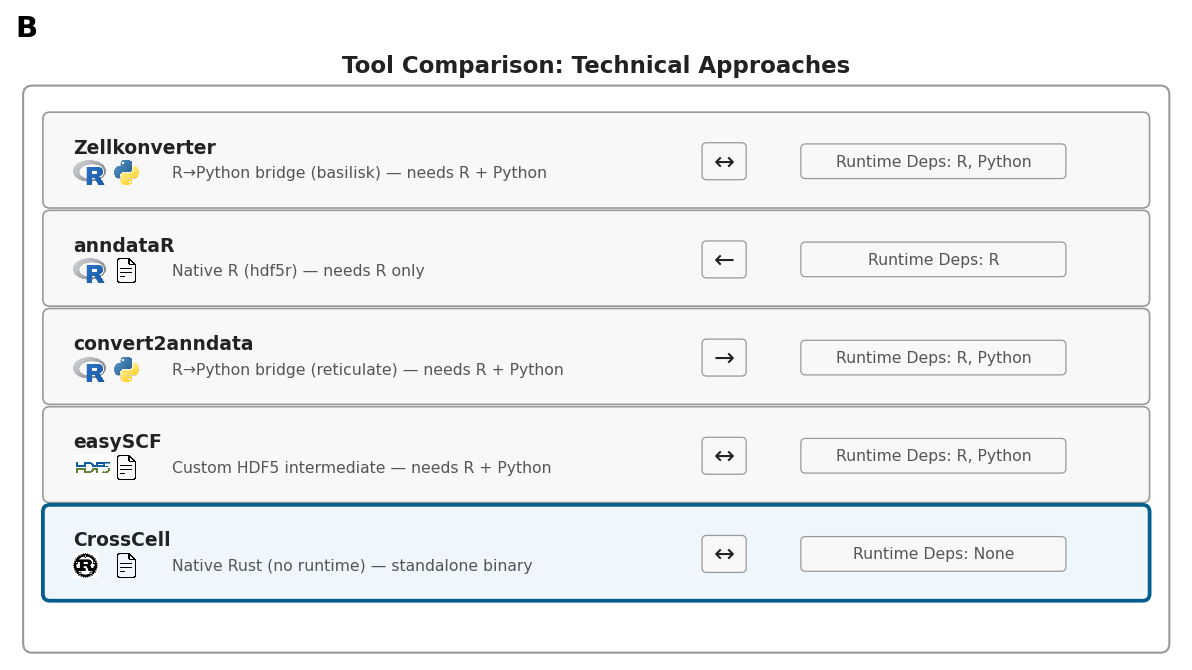

In [4]:

fig, ax = plt.subplots(figsize=(10, 5.25))
draw_panel_b(ax)
ax.set_title('B', fontsize=14, fontweight='bold', loc='left', pad=6)
fig.savefig(FIGURES_DIR / 'fig1b_tool_landscape.pdf', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIGURES_DIR / 'fig1b_tool_landscape.png', dpi=300, bbox_inches='tight', facecolor='white')
print('Saved fig1b')
plt.show()


## 4. Fig 1C: Evaluation Framework (standalone)

Saved fig1c


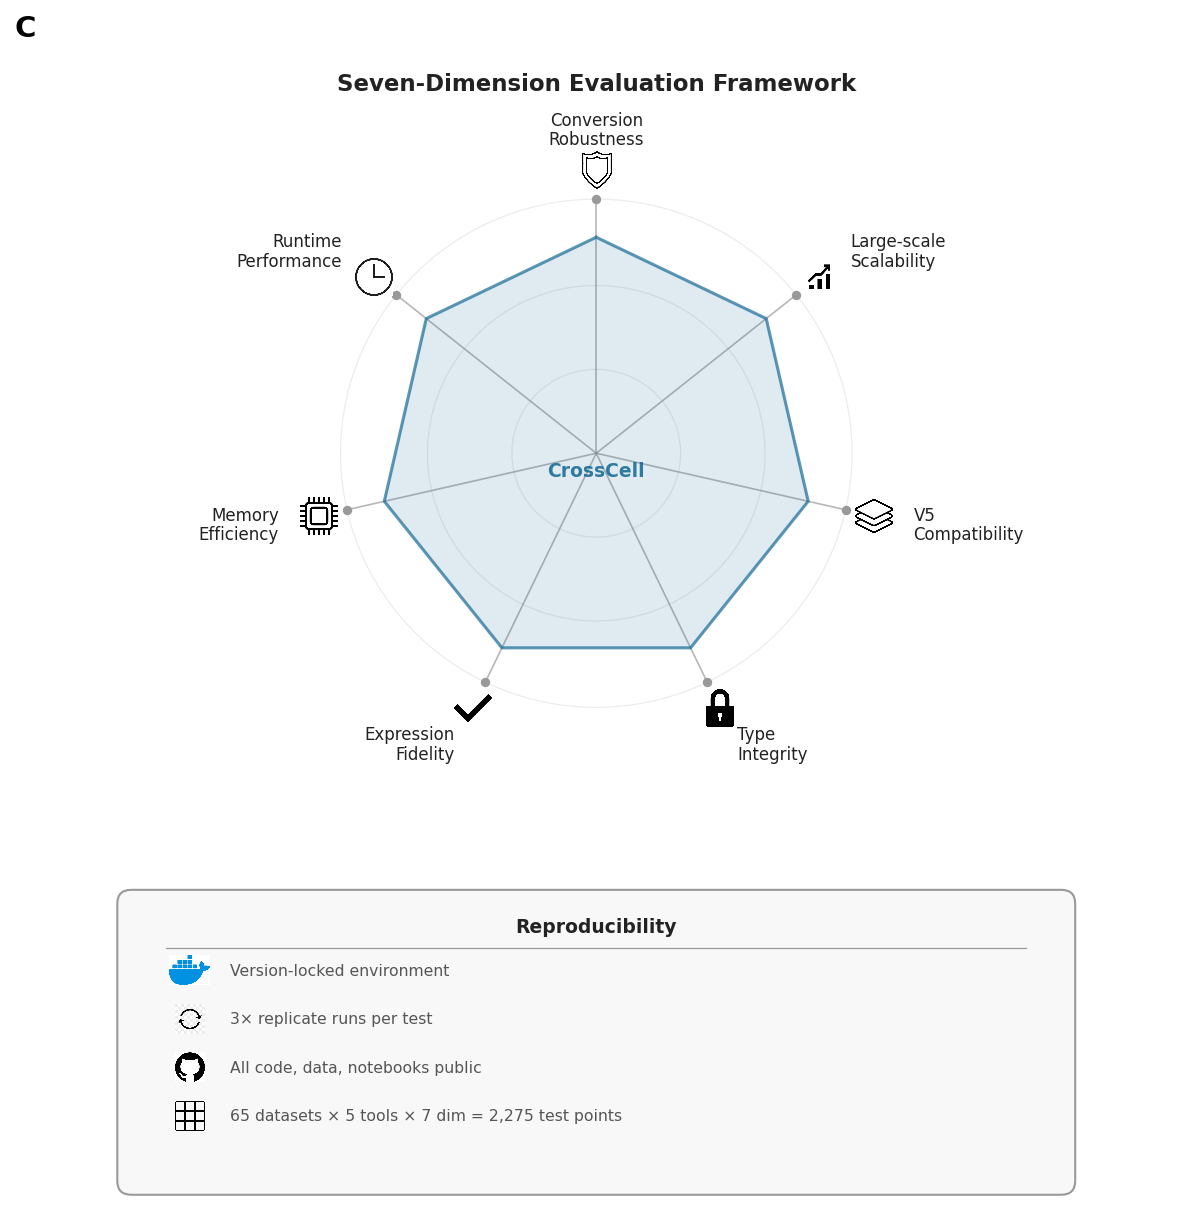

In [5]:

fig, ax = plt.subplots(figsize=(10, 10))
draw_panel_c(ax)
ax.set_title('C', fontsize=14, fontweight='bold', loc='left', pad=6)
fig.savefig(FIGURES_DIR / 'fig1c_evaluation_framework.pdf', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIGURES_DIR / 'fig1c_evaluation_framework.png', dpi=300, bbox_inches='tight', facecolor='white')
print('Saved fig1c')
plt.show()


## 5. Composite Figure 1 (A + B + C)

Saved fig1_composite


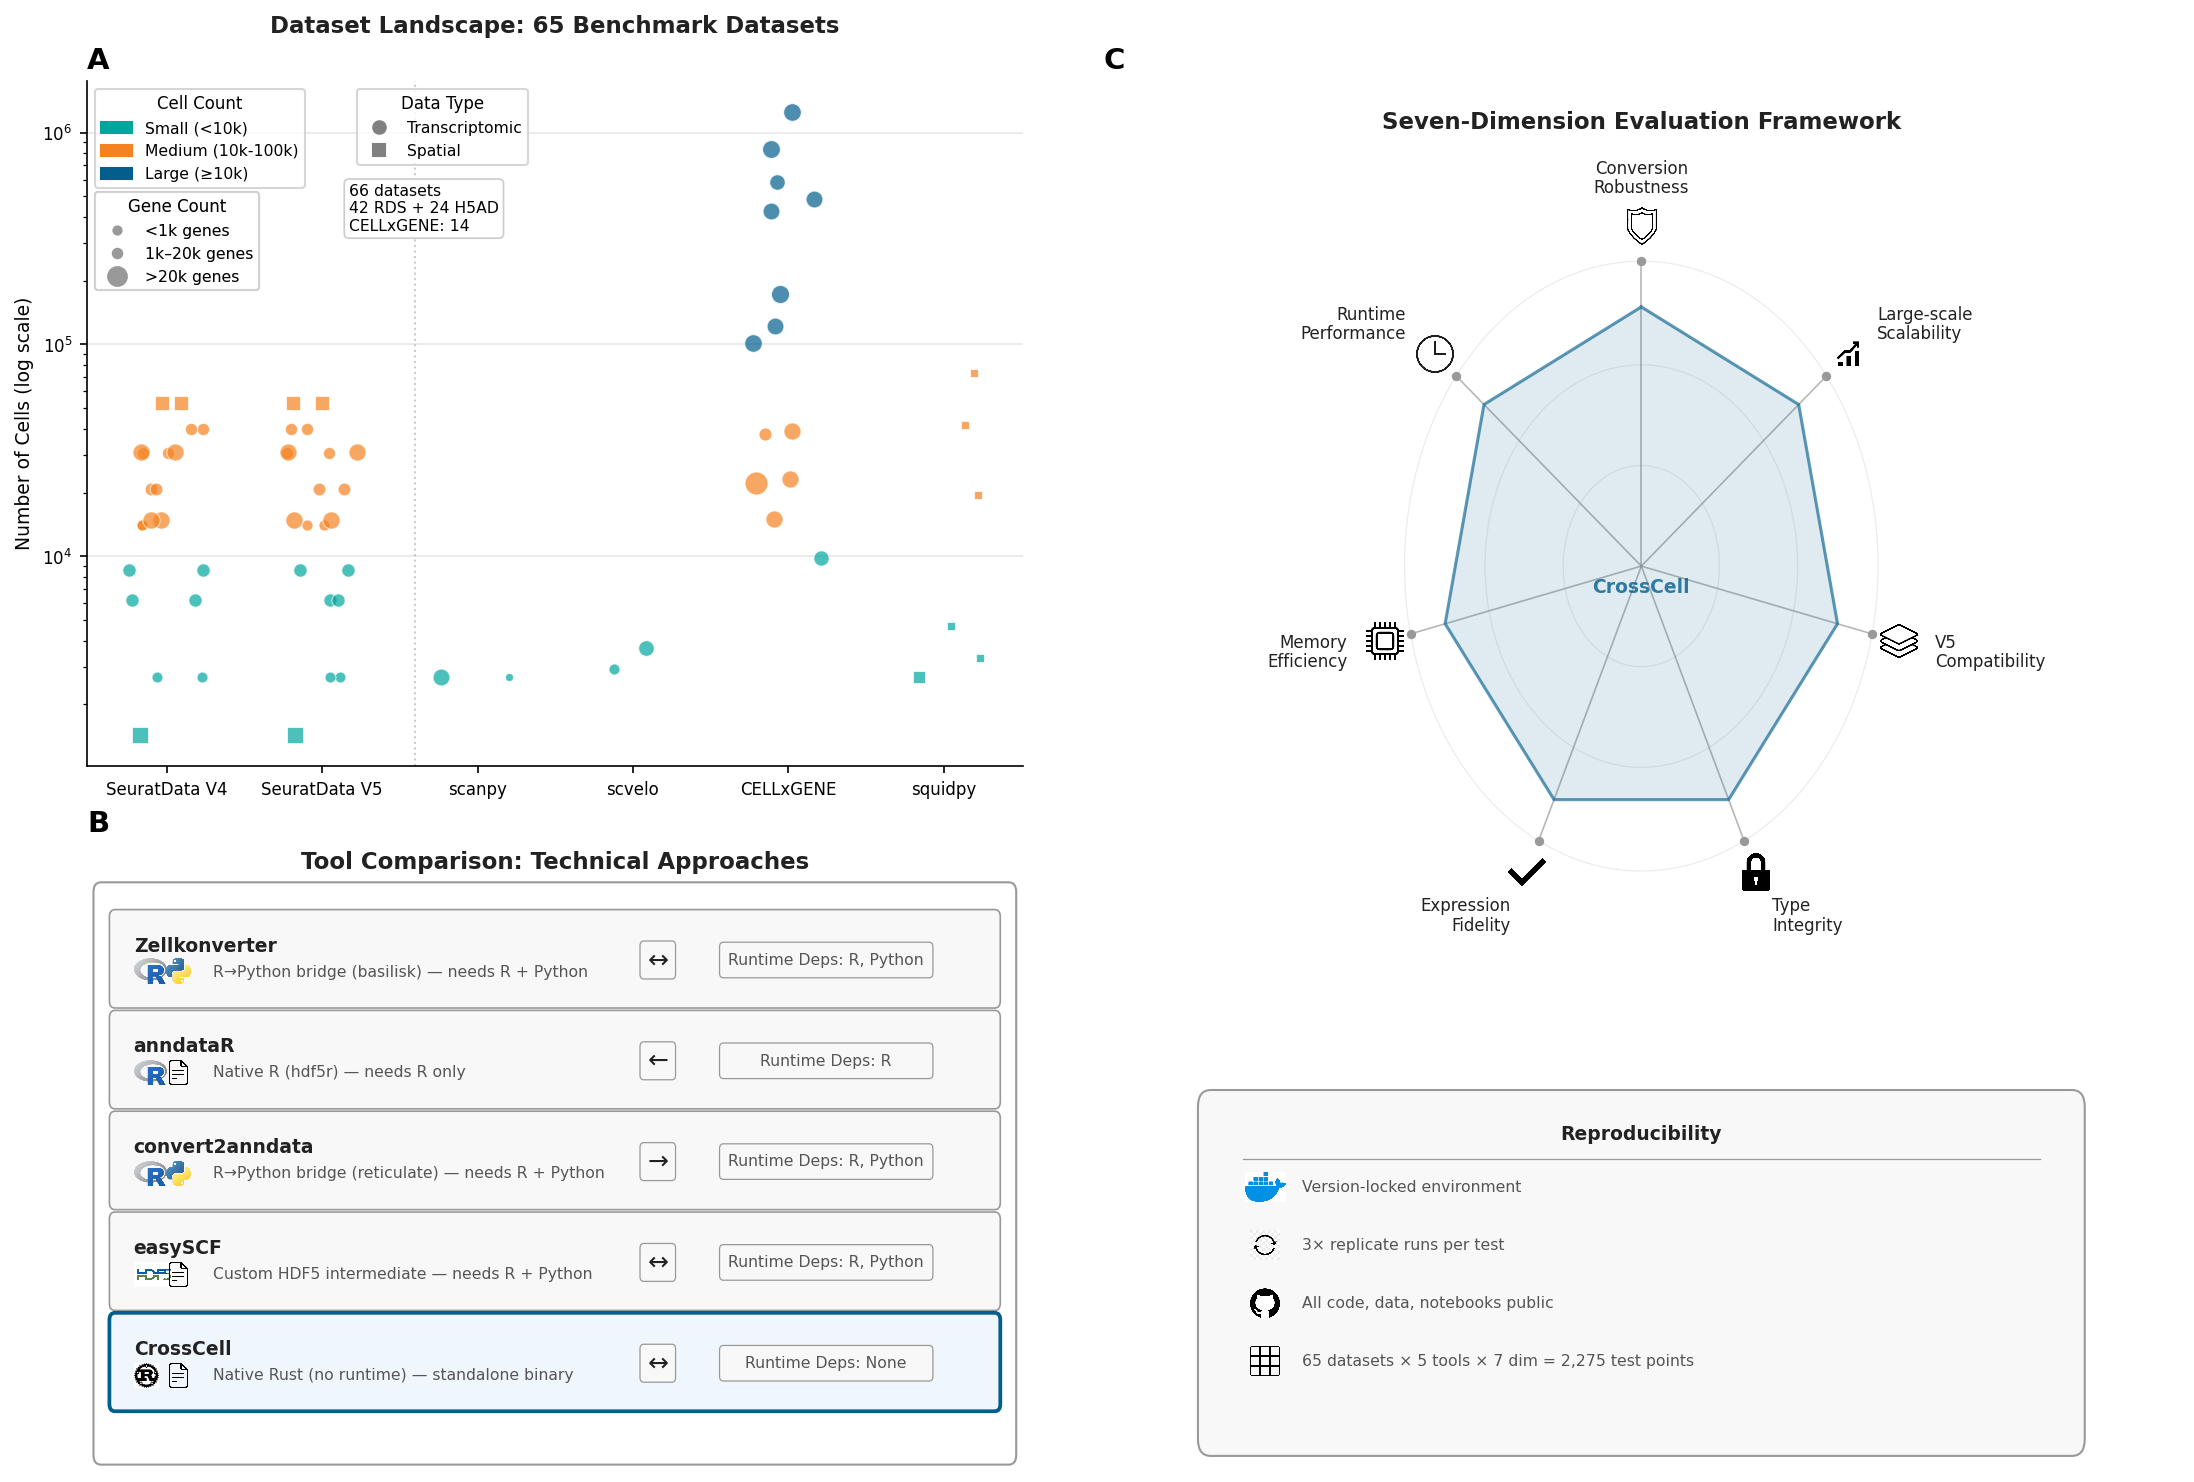

In [6]:

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 2, figure=fig,
              width_ratios=[1, 1.15],
              height_ratios=[1.1, 1],
              hspace=0.12, wspace=0.08)

# Panel A: top-left
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_title('A', fontsize=14, fontweight='bold', loc='left', pad=6)
draw_panel_a(ax_a, rows, source_order)

# Panel B: bottom-left
ax_b = fig.add_subplot(gs[1, 0])
ax_b.set_title('B', fontsize=14, fontweight='bold', loc='left', pad=6)
draw_panel_b(ax_b)

# Panel C: right, full height
ax_c = fig.add_subplot(gs[:, 1])
ax_c.set_title('C', fontsize=14, fontweight='bold', loc='left', pad=6)
draw_panel_c(ax_c)

fig.savefig(FIGURES_DIR / 'fig1_composite.pdf', dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(FIGURES_DIR / 'fig1_composite.png', dpi=300, bbox_inches='tight', facecolor='white')
print('Saved fig1_composite')
plt.show()


In [7]:

print('Figure 1 complete: 1A, 1B, 1C (standalone) + composite.')


Figure 1 complete: 1A, 1B, 1C (standalone) + composite.
